ランキングを作成中...


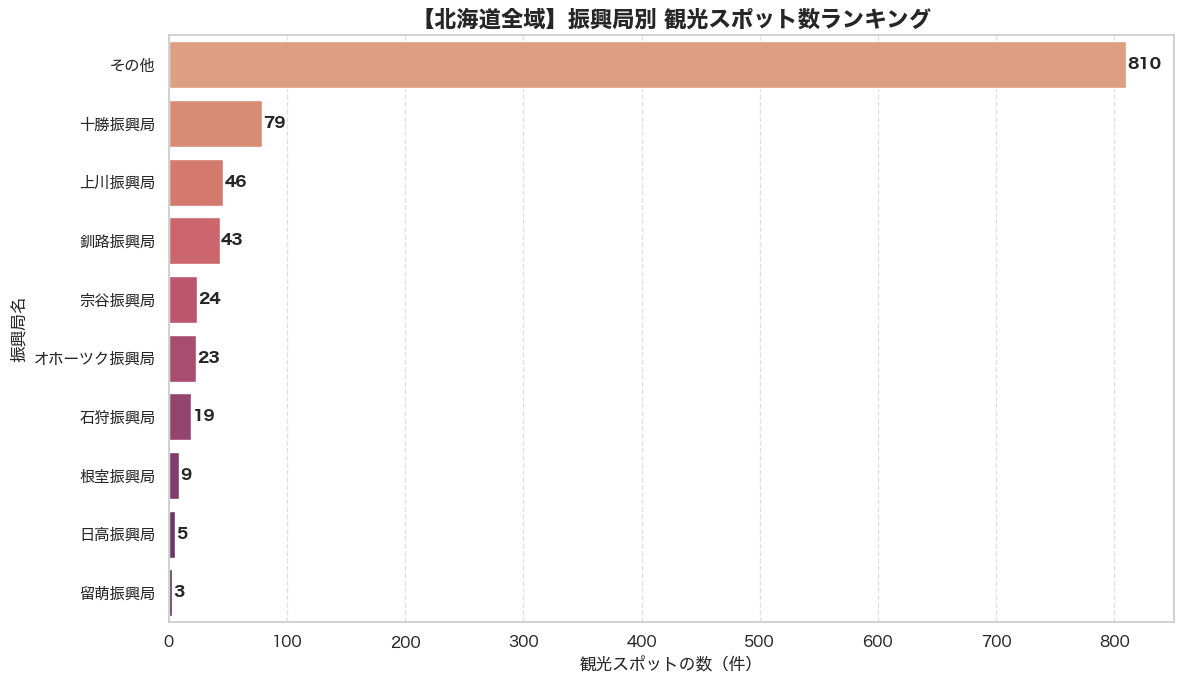


💡 分析結果：北海道で最も観光スポットが登録されているのは「その他」で、810件でした！


In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'Noto Sans CJK JP', 'IPAexGothic']

class HokkaidoSimpleAnalyzer:
    def __init__(self, db_name="hokkaido_tourism_final.db"):
        self.db_name = db_name

    def show_ranking(self):
        """北海道全域の振興局別・観光スポット数ランキングを表示"""
        with sqlite3.connect(self.db_name) as conn:
            query = """
                SELECT subpref, COUNT(spot_name) as spot_count 
                FROM spots 
                GROUP BY subpref 
                ORDER BY spot_count DESC
            """
            df = pd.read_sql(query, conn)

        if df.empty:
            print("データがありません。先にスクレイピングを実行してください。")
            return

        # グラフ作成
        plt.figure(figsize=(12, 7))
        # 順位に応じて色を変える設定
        sns.barplot(x='spot_count', y='subpref', data=df, palette='flare', hue='subpref', legend=False)
        
        plt.title('【北海道全域】振興局別 観光スポット数ランキング', fontsize=16, fontweight='bold')
        plt.xlabel('観光スポットの数（件）', fontsize=12)
        plt.ylabel('振興局名', fontsize=12)
        
        # 棒の横に件数を表示
        for i, v in enumerate(df['spot_count']):
            plt.text(v + 1, i, str(int(v)), va='center', fontsize=11, fontweight='bold')

        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        
        return df

# --- 実行 ---
analyzer = HokkaidoSimpleAnalyzer()
print("ランキングを作成中...")
rank_df = analyzer.show_ranking()

# 1位の場所を強調して表示
if not rank_df.empty:
    top_subpref = rank_df.iloc[0]['subpref']
    top_count = rank_df.iloc[0]['spot_count']
    print(f"\n💡 分析結果：北海道で最も観光スポットが登録されているのは「{top_subpref}」で、{top_count}件でした！")